# NB2 _ Exploratory Data Analysis (EDA)
## Goal 
- Understand the price distribution
- Identify key drivers of house prices
- Spot patterns by size, qulaity and location
- Generate insights to guide feature engineering and modeling

### Set Up

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Projects/03_Advanced_house_price _predictor/data/cleaned/house_price_cleaned_data.csv")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,221900.0,3,1.00,1180.0,5650.0,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650.0
1,6414100192,2014-12-09,538000.0,3,2.25,2570.0,7242.0,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639.0
2,5631500400,2015-02-25,180000.0,2,1.00,770.0,10000.0,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062.0
3,2487200875,2014-12-09,604000.0,4,3.00,1960.0,5000.0,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000.0
4,1954400510,2015-02-18,510000.0,3,2.00,1680.0,8080.0,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503.0


### 1. Target Variable: Price Distribution

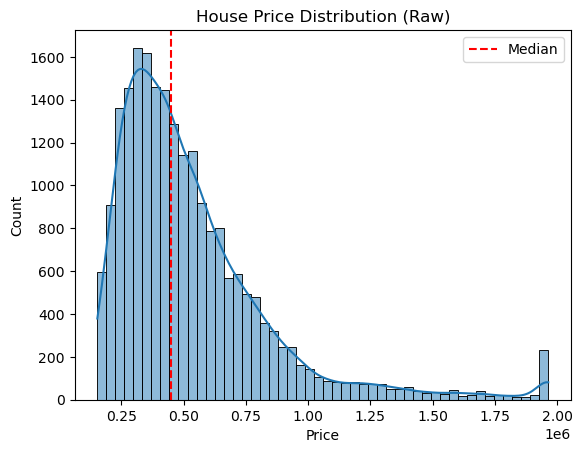

In [11]:
# Raw Price distribution
plt.figure()
sns.histplot(df["price"], bins=50, kde=True)
plt.axvline(df["price"].median(), color="red", linestyle="--", label="Median")
plt.legend()
plt.title("House Price Distribution (Raw)")
plt.xlabel("Price")
plt.show()

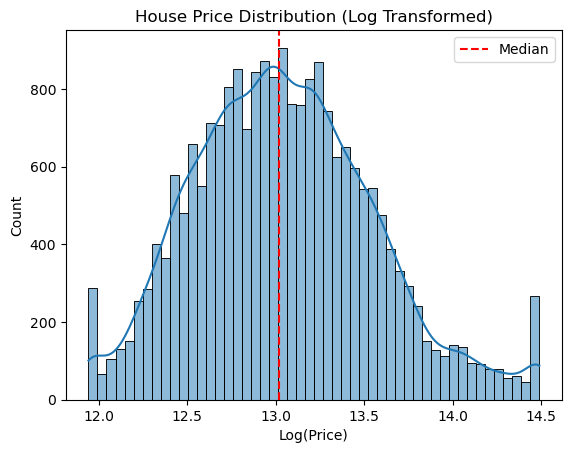

In [12]:
# log-transformed price
df["log_price"] = np.log1p(df["price"])

plt.figure()
sns.histplot(df["log_price"], bins=50, kde=True)
plt.axvline(df["log_price"].median(), color="red", linestyle="--", label="Median")
plt.legend()
plt.title("House Price Distribution (Log Transformed)")
plt.xlabel("Log(Price)")
plt.show()

Raw house price are highly right-skewed with a small number of very expensive properties and log transformation of price normalizes the distribution, making it more suitable for regression modeling.

### 2. Relationship with house size

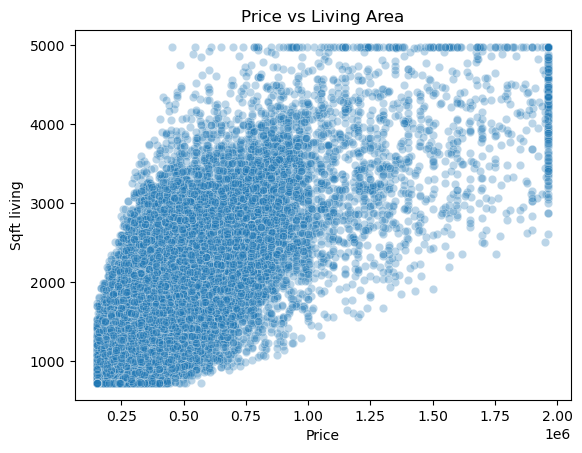

In [26]:
# Living area vs price

plt.figure()
sns.scatterplot(x="price", y="sqft_living", data=df, alpha=0.3)
plt.title("Price vs Living Area")
plt.xlabel("Price")
plt.ylabel("Sqft living")
plt.show()

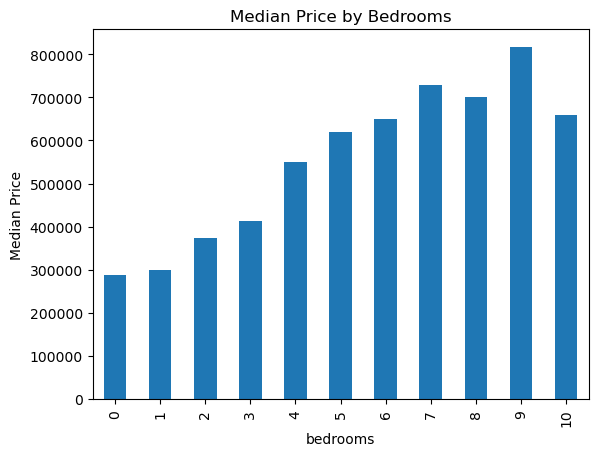

In [28]:
# bedroom vs price

df_bed = df[df["bedrooms"] <= 10]
df_bed.groupby("bedrooms")["price"].median().plot(kind="bar")
plt.title("Median Price by Bedrooms")
plt.ylabel("Median Price")
plt.show()


Generally price increase with bedroom count, but the reationship is weaker and less cosistent.

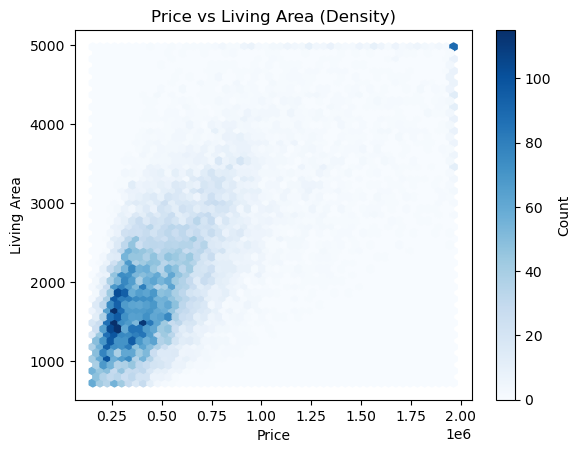

In [29]:
# Hexbin

plt.figure()
plt.hexbin(df["price"], df["sqft_living"], gridsize=50, cmap="Blues")
plt.colorbar(label="Count")
plt.xlabel("Price")
plt.ylabel("Living Area")
plt.title("Price vs Living Area (Density)")
plt.show()

Living area show a strong positive relationship with house price, with most transactions are clustered between 1000-2000 sqft and the price $200K - $5000 K. This plot shows that the living area strongly influcences price.

### 3. House Quality 

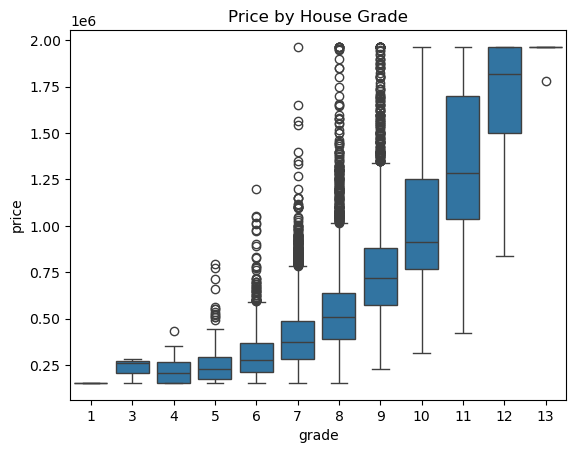

In [6]:
# Grade vs Price
plt.figure()
sns.boxplot(x="grade", y="price", data=df)
plt.title("Price by House Grade")
plt.show()

House grade shows a strong and consistent positive relationship with price. Higher-grade houses command significantly higher prices, making grade one of the most important quality-related predictors.

C:\Users\shwey\AppData\Local\Temp\ipykernel_5352\2044872965.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("bathroom_bin")["price"].median().plot(kind="bar")


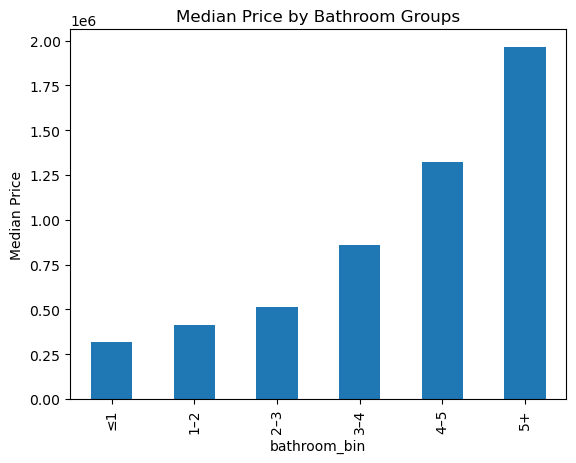

In [31]:
# Bathrooms vs price

df["bathroom_bin"] = pd.cut(
    df["bathrooms"],
    bins=[0,1,2,3,4,5,10],
    labels=["≤1","1–2","2–3","3–4","4–5","5+"]
)

df.groupby("bathroom_bin")["price"].median().plot(kind="bar")
plt.title("Median Price by Bathroom Groups")
plt.ylabel("Median Price")
plt.show()


Bathrooms are positively associated with price, but their effect largely reflects overall house size and quality.

### 4. Location Effect 

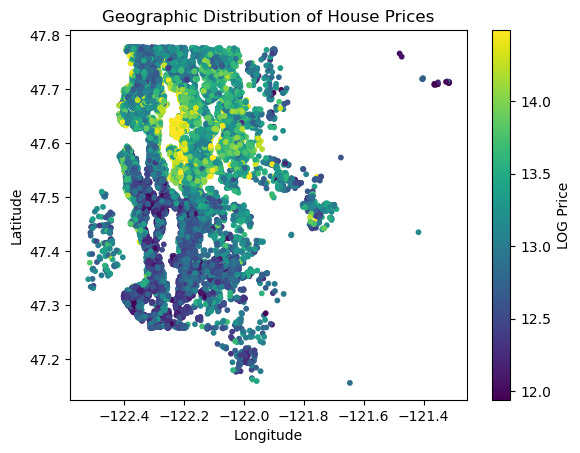

In [ ]:
# Geographic Visualization
plt.figure()
plt.scatter(df["long"], df["lat"], c=df["log_price"], cmap="viridis", s=10)
plt.colorbar(label="LOG Price")
plt.title("Geographic Distribution of House Prices")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


Location influences house prices, as evidenced by spatial patterns and localized high-price areas.

### 5. Correlation Analysis

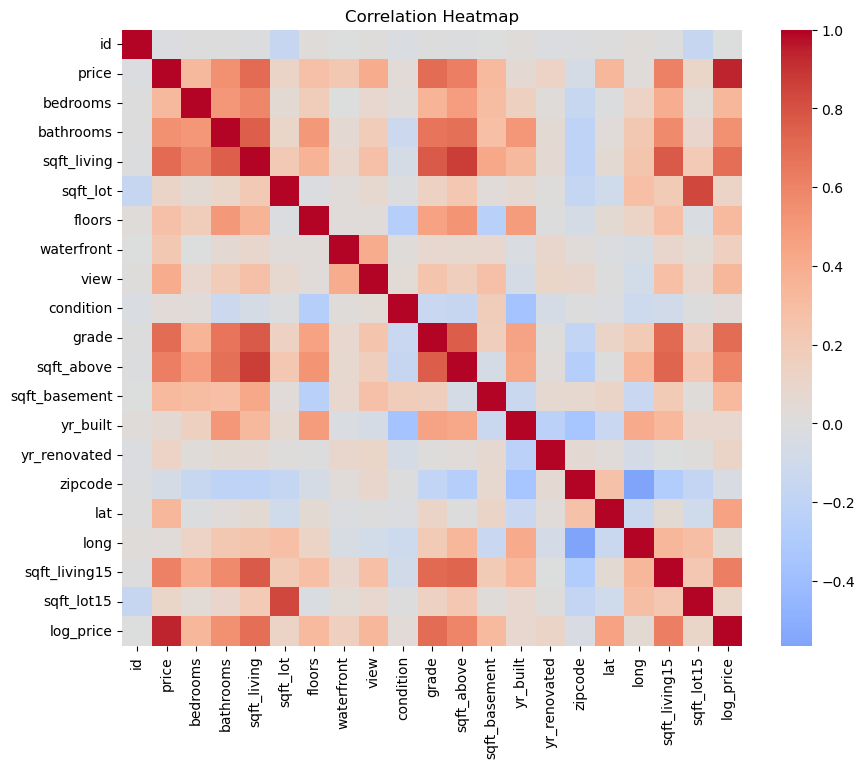

In [10]:
num_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(num_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

- The correlation analysis shows that house price is strongly positively correlated with living area, house grade, and number of bathrooms, indicating that size and quality are the primary drivers of price. 
- Bedrooms, floors, and view exhibit moderate correlations, while lot size and condition show weak linear relationships. 
- Geographic variables such as latitude, longitude, and zipcode have low linear correlation with price, suggesting that location effects are non-linear and better captured through spatial analysis rather than correlation alone.

### EDA Summary
House price are mainly influenced by **size, quality and location**.
